<a href="https://colab.research.google.com/github/Naomy-Yailin/SIS420/blob/main/02_reg_lin_mul_Driver_Behavior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de programación: Regresión Lineal Múltiple
## Dataset: Driver Behavior (Comportamiento del Conductor)

In [1]:
# Utilizado para manejo de directorios y rutas
import os

# Cómputo vectorial y científico para Python
import numpy as np
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Embebe gráficas dentro del cuadernillo
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


## 1. Carga de datos

El archivo `Driver_Behavior.csv` contiene 30,000 registros de conducción con las siguientes columnas:

| Columna | Descripción |
|---|---|
| `speed_kmph` | Velocidad en km/h |
| `accel_x` | Aceleración longitudinal |
| `accel_y` | Aceleración lateral |
| `brake_pressure` | Presión de freno |
| `steering_angle` | Ángulo de dirección |
| `throttle` | Acelerador (%) |
| `lane_deviation` | Desviación de carril |
| `phone_usage` | Uso del teléfono (0/1) |
| `headway_distance` | Distancia al vehículo de adelante |
| `reaction_time` | **Variable objetivo: tiempo de reacción (segundos)** |
| `behavior_label` | Etiqueta categórica de comportamiento |

**Objetivo:** Predecir el `reaction_time` usando las 9 variables numéricas como features.

In [7]:
# Cargar datos desde CSV con pandas
data = pd.read_csv('/content/gdrive/MyDrive/sis420/datasets/Driver_Behavior.csv')  # Ajusta la ruta si es necesario

# Definir las columnas de features (variables independientes)
feature_cols = ['speed_kmph', 'accel_x', 'accel_y', 'brake_pressure',
                'steering_angle', 'throttle', 'lane_deviation',
                'phone_usage', 'headway_distance']

# Extraer matrices X (features) e y (variable objetivo)
X = data[feature_cols].values   # Shape: (30000, 9)
y = data['reaction_time'].values  # Shape: (30000,)
m = y.size

print(f'Número de ejemplos de entrenamiento: m = {m}')
print(f'Número de features: n = {X.shape[1]}')
print()

# Mostrar los primeros 10 registros
print('Primeros 10 registros (speed_kmph | reaction_time):')
print(f'{"speed_kmph":>12s} {"reaction_time":>14s}')
print('-' * 28)
for i in range(10):
    print(f'{X[i, 0]:>12.2f} {y[i]:>14.4f}')

Número de ejemplos de entrenamiento: m = 30000
Número de features: n = 9

Primeros 10 registros (speed_kmph | reaction_time):
  speed_kmph  reaction_time
----------------------------
       36.08         1.4000
       38.09         1.4285
       71.31         0.4069
       86.49         0.5400
       52.82         1.3699
       42.99         0.9838
       61.73         0.9676
       52.97         0.8579
       54.35         0.9186
       59.05         1.4890


## 2. Normalización de características

Las 9 features tienen escalas muy diferentes (ej. `speed_kmph` varía entre 20–118, mientras `phone_usage` es 0 o 1). **Normalizar** transforma cada feature para que tenga media ≈ 0 y desviación estándar ≈ 1, lo que permite que el descenso por el gradiente converja más rápidamente.

$$x_{norm} = \frac{x - \mu}{\sigma}$$

> **Importante:** guardar `mu` y `sigma` para normalizar nuevas predicciones más adelante.

In [8]:
def featureNormalize(X):
    """
    Normaliza las features de X.
    Retorna:
        X_norm : features normalizadas
        mu     : media de cada feature
        sigma  : desviación estándar de cada feature
    """
    mu    = np.mean(X, axis=0)   # Media de cada columna
    sigma = np.std(X, axis=0)    # Desv. estándar de cada columna
    X_norm = (X - mu) / sigma    # Normalización z-score
    return X_norm, mu, sigma

In [9]:
# Aplicar normalización
X_norm, mu, sigma = featureNormalize(X)

# Mostrar estadísticos
print('Medias calculadas por feature:')
for name, val in zip(feature_cols, mu):
    print(f'  {name:>20s}: {val:.4f}')

print()
print('Desviaciones estándar calculadas:')
for name, val in zip(feature_cols, sigma):
    print(f'  {name:>20s}: {val:.4f}')

# Verificar que X_norm tiene media ≈ 0 y std ≈ 1
print()
print('Verificación (media de X_norm ≈ 0):', np.round(np.mean(X_norm, axis=0), 4))

Medias calculadas por feature:
            speed_kmph: 59.9864
               accel_x: 1.2658
               accel_y: 0.3685
        brake_pressure: 40.7676
        steering_angle: -0.0402
              throttle: 55.0012
        lane_deviation: 0.5685
           phone_usage: 0.3333
      headway_distance: 23.3992

Desviaciones estándar calculadas:
            speed_kmph: 14.8058
               accel_x: 1.0266
               accel_y: 0.2956
        brake_pressure: 26.7213
        steering_angle: 11.3839
              throttle: 21.4750
        lane_deviation: 0.4206
           phone_usage: 0.4714
      headway_distance: 11.9983

Verificación (media de X_norm ≈ 0): [-0. -0.  0. -0.  0.  0.  0.  0. -0.]


In [10]:
# Agregar el término de intersección (columna de unos) como x0 = 1
# Esto permite que theta[0] sea el bias (intersección) del modelo
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f'Dimensiones de X con intersección: {X.shape}')  # (30000, 10)
print('Primeras 3 filas de X:')
print(X[:3, :])

Dimensiones de X con intersección: (30000, 10)
Primeras 3 filas de X:
[[ 1.         -1.6150074  -0.71113341  1.15045931 -0.66088938 -0.27492774
  -0.08743752  0.67368636  1.41421356 -0.45032934]
 [ 1.         -1.47887625 -0.28448485 -1.09653415 -0.14245151 -2.13809703
  -0.86693128  2.11849608  1.41421356  0.54216194]
 [ 1.          0.76510898  2.31112342  1.42356061  1.45825575 -0.53233362
   1.07610347 -0.74621563 -0.70710678 -1.02291128]]


## 3. Descenso por el Gradiente

### 3.1 Función de Costo

$$J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y})$$

### 3.2 Regla de actualización

$$\theta := \theta - \frac{\alpha}{m} X^T(X\theta - \vec{y})$$

Donde `alpha` es la tasa de aprendizaje y `num_iters` el número de iteraciones.

In [11]:
def computeCostMulti(X, y, theta):
    """
    Calcula el costo J(theta) para regresión lineal múltiple.
    """
    m = y.shape[0]
    # Error = X*theta - y  |  Costo = (1/2m) * sum(error^2)
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [12]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    """
    Ejecuta el descenso por el gradiente para minimizar J(theta).
    Retorna theta optimizado y el historial de costos.
    """
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        # Actualización vectorizada de theta
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

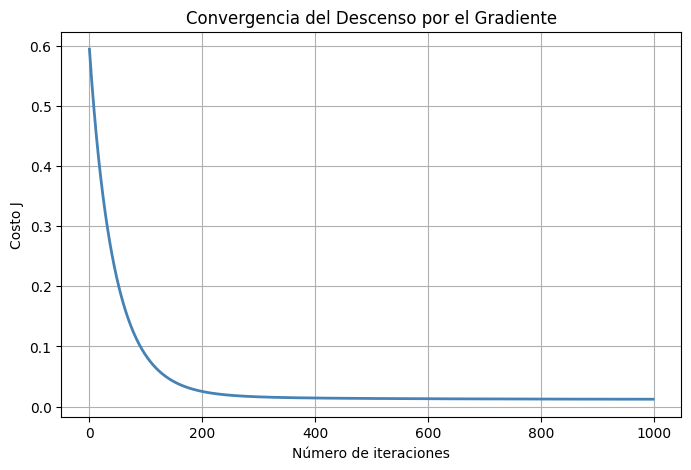

Theta calculado por el descenso por el gradiente:
                  bias: 0.999774
            speed_kmph: -0.021237
               accel_x: -0.041964
               accel_y: -0.009166
        brake_pressure: -0.029027
        steering_angle: 0.001155
              throttle: -0.038410
        lane_deviation: 0.018070
           phone_usage: 0.375591
      headway_distance: 0.011337

Costo final J = 0.012280


In [13]:
# Hiperparámetros
alpha = 0.01        # Tasa de aprendizaje
num_iters = 1000    # Número de iteraciones

# Inicializar theta en ceros (10 valores: 1 bias + 9 features)
theta = np.zeros(X.shape[1])

# Ejecutar descenso por el gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Graficar convergencia del costo
pyplot.figure(figsize=(8, 5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='steelblue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.grid(True)
pyplot.show()

print('Theta calculado por el descenso por el gradiente:')
for name, val in zip(['bias'] + feature_cols, theta):
    print(f'  {name:>20s}: {val:.6f}')
print(f'\nCosto final J = {J_history[-1]:.6f}')

In [14]:
# Predecir el tiempo de reacción para un conductor con estos valores:
# speed=60 km/h, accel_x=1.5, accel_y=0.5, brake=40, steering=5,
# throttle=50, lane_dev=0.5, phone=0, headway=20

sample = np.array([60, 1.5, 0.5, 40, 5, 50, 0.5, 0, 20])

# IMPORTANTE: normalizar con los mismos mu y sigma del entrenamiento
sample_norm = (sample - mu) / sigma

# Agregar el término de intersección
X_pred = np.concatenate([[1], sample_norm])

# Predicción
pred_gd = np.dot(X_pred, theta)

print('=== Predicción (Descenso por el Gradiente) ===')
print(f'  speed_kmph      = {sample[0]}')
print(f'  accel_x         = {sample[1]}')
print(f'  brake_pressure  = {sample[3]}')
print(f'  phone_usage     = {int(sample[7])}')
print(f'  headway_distance= {sample[8]}')
print(f'\n  → Tiempo de reacción predicho: {pred_gd:.4f} segundos')

=== Predicción (Descenso por el Gradiente) ===
  speed_kmph      = 60.0
  accel_x         = 1.5
  brake_pressure  = 40.0
  phone_usage     = 0
  headway_distance= 20.0

  → Tiempo de reacción predicho: 0.7247 segundos


## 4. Ecuación Normal

Una alternativa al descenso por el gradiente es la solución analítica exacta:

$$\theta = (X^T X)^{-1} X^T \vec{y}$$

**Ventajas:** No requiere elegir `alpha`, convergencia en un solo cálculo.  
**Desventajas:** Costoso computacionalmente cuando hay muchas features (escala como O(n³)).  

> ⚠️ Con la Ecuación Normal **NO** es necesario normalizar las features.

In [18]:
# Recargar datos SIN normalizar (la Ecuación Normal no lo requiere)
data2 = pd.read_csv('/content/gdrive/MyDrive/sis420/datasets/Driver_Behavior.csv')
X2 = data2[feature_cols].values
y2 = data2['reaction_time'].values
m2 = y2.size

# Agregar columna de unos para el término de intersección
X2 = np.concatenate([np.ones((m2, 1)), X2], axis=1)
print(f'Dimensiones de X2: {X2.shape}')  # (30000, 10)

Dimensiones de X2: (30000, 10)


In [19]:
def normalEqn(X, y):
    """
    Calcula theta mediante la Ecuación Normal.
    theta = (X^T X)^{-1} X^T y
    """
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

In [20]:
# Calcular theta con la Ecuación Normal
theta_normal = normalEqn(X2, y2)

print('Theta calculado con la Ecuación Normal:')
for name, val in zip(['bias'] + feature_cols, theta_normal):
    print(f'  {name:>20s}: {val:.6f}')

# Predicción con los mismos valores de ejemplo
# NO se normaliza porque la Ecuación Normal trabaja con valores originales
sample2 = np.array([1, 60, 1.5, 0.5, 40, 5, 50, 0.5, 0, 20])  # incluye el 1 para bias
pred_ne = np.dot(sample2, theta_normal)

print(f'\n=== Predicción (Ecuación Normal) ===')
print(f'  → Tiempo de reacción predicho: {pred_ne:.4f} segundos')

print('\n=== Comparación ===')
print(f'  Descenso por el gradiente: {np.dot(np.concatenate([[1], (np.array([60,1.5,0.5,40,5,50,0.5,0,20]) - mu)/sigma]), theta):.4f} s')
print(f'  Ecuación Normal:           {pred_ne:.4f} s')

Theta calculado con la Ecuación Normal:
                  bias: 0.868985
            speed_kmph: -0.000663
               accel_x: -0.023880
               accel_y: -0.040311
        brake_pressure: -0.001190
        steering_angle: 0.000088
              throttle: -0.001400
        lane_deviation: -0.019006
           phone_usage: 0.886172
      headway_distance: 0.002419

=== Predicción (Ecuación Normal) ===
  → Tiempo de reacción predicho: 0.6950 segundos

=== Comparación ===
  Descenso por el gradiente: 0.7247 s
  Ecuación Normal:           0.6950 s
